# T61 — Reference-frame uncertainty in reconstructed paleoclimate

**Cluster J: Paleoclimate.**

*Based on:* Leonard, J.S., Mather, B.R., Merdith, A.S., Zahirovic, S., Williams, S.E., Müller, R.D. (2025). *Polar wander leads to large differences in past climate*. **Communications Earth & Environment** — using PLASIM-GENIE atmospheric snapshots re-run inside three different absolute-plate-motion reference frames.

## What this notebook produces

Deep-time paleoclimate reconstructions have to choose an *absolute* plate reference frame — the answer to "where was continent X, in absolute-mantle coordinates, at age t?". That choice is far less well-constrained than the *relative* motions between plates, and it changes the paleo-continents' latitudinal positions by up to tens of degrees through the Phanerozoic. **This notebook re-produces two of the paper's headline figures showing how much the choice of frame matters for reconstructed climate at every age.**

1. **§3 — Map comparison.** For each of 5 target ages (210, 170, 130, 90, 40 Ma), a four-panel row of maps: (a) surface air temperature in the *Merdith 2021 paleomagnetic frame*, (b) the same field in the *Müller 2016 hybrid mantle frame*, (c) the pixel-wise ΔT, (d) the pixel-wise Δ|latitude| between the two frames' reconstructed positions. Reproduces Leonard 2025 Fig 3.
2. **§4 — Latitude-age heatmaps.** Zonal-mean SAT as a function of latitude and age for each frame, plus their difference. Reproduces Leonard 2025 Fig 4.
3. **§5 (bonus) — Global-mean SAT time series.** Both frames' area-weighted GMST as a function of age, to give one-liner headline numbers for how much the frame choice shifts the whole planet's inferred temperature history.

## Learning objectives

- Load and manipulate PLASIM-GENIE atmospheric outputs (`puma_temperature_surface_air`) with xarray.
- Compare climate fields between plate reference frames using pixel-wise differences.
- Visualise 2-D fields (frame × frame × difference) as pyGMT subplot rows.
- Render a latitude × age heatmap in matplotlib for zonal-mean comparisons.

## Prerequisites and runtime

- Bundled data at `data/leonard_2025_paleoclimate/` (~2 MB): 3 frames × 26 ages × 3 vars (SAT + landsea + orography). Extracted from the full 384 MB source archive at <https://zenodo.org/records/15628277> (Leonard et al. 2025 CommsEarthEnv).
- Python: `xarray`, `numpy`, `pygmt`, `matplotlib`, `pandas`.
- Runtime: ~30 s for §3 (5 rows × 4 maps), ~5 s for §4 heatmaps, ~2 s for the bonus.

## Sources

- Leonard, J.S., Mather, B.R., Merdith, A.S., Zahirovic, S., Williams, S.E., Müller, R.D. (2025). Polar wander leads to large differences in past climate. *Communications Earth & Environment* (in press).
- Full paper archive: <https://zenodo.org/records/15628277>.


## Data availability

**Bundled data** at `data/leonard_2025_paleoclimate/` (~2 MB total):

- `merdith2021_paleomag/{0..250}Ma.nc` — PLASIM-GENIE simulation output re-cast into the Merdith et al. (2021) paleomagnetic reference frame (26 files, one per 10-Myr timestep).
- `muller2016_mantle/{0..250}Ma.nc` — same PLASIM-GENIE model output re-cast into the Müller et al. (2016) hybrid mantle reference frame (26 files).
- `torsvik2019_paleomag/{0..250}Ma.nc` — bonus third frame (Torsvik et al. 2019) for cross-checking against the Earthbyte reference frames (26 files).

Each NC carries three variables at 32 × 64 native PLASIM resolution: `puma_temperature_surface_air` (°C, annual mean), `grid_landsea_mask` (0-1), and `grid_orography` (m). The full Leonard 2025 archive (384 MB, 5 frames × ~15 vars × 26 ages) is at Zenodo.

**License**: CC BY 4.0 (Leonard et al. 2025 Zenodo record 15628277).

## Sources

- Leonard, J.S., Mather, B.R., Merdith, A.S., Zahirovic, S., Williams, S.E., Müller, R.D. (2025). Polar wander leads to large differences in past climate. *Communications Earth & Environment*.
- Merdith, A.S. et al. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477.
- Müller, R.D. et al. (2016). Ocean basin evolution and global-scale plate reorganization events since Pangea breakup. *Annual Review of Earth and Planetary Sciences* 44, 107-138.
- Torsvik, T.H. & Cocks, L.R.M. (2019). *Earth history and palaeogeography*. Cambridge University Press.


## Environment + imports


In [21]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import pygmt

# House-style Mollweide/Robinson rim fix for coarse GCM output (T45-T48 pattern).
sys.path.insert(0, str(Path("Notebooks").resolve()))
from paleoclimate_helpers import refine_for_plot

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  pygmt       v0.18.0


In [22]:
# === USER CONFIGURATION =====================================================
# Reference frames to compare (folder names under data/leonard_2025_paleoclimate/).
FRAME_A_DIR    = Path("data/leonard_2025_paleoclimate/merdith2021_paleomag")
FRAME_B_DIR    = Path("data/leonard_2025_paleoclimate/muller2016_mantle")
FRAME_A_LABEL  = "Merdith 2021 (paleomagnetic)"
FRAME_B_LABEL  = "Müller 2016 (hybrid mantle)"

# The five snapshot ages for the §3 map-comparison grid (matches Leonard 2025 Fig 3)
SNAPSHOT_AGES_MA = [210, 170, 130, 90, 40]

# All ages available in the bundle (0-250 Ma at 10-Myr cadence). Used by §4/§5.
ALL_AGES_MA      = list(range(0, 260, 10))

# Variable to compare — PLASIM annual-mean surface air temperature (°C)
VAR              = "puma_temperature_surface_air"

# Colour-bar ranges
SAT_RANGE_C      = (-30, 50, 5)     # absolute SAT (°C)
DIFF_RANGE_C     = (-15, 15, 1)     # ΔSAT between frames (°C)
LATDIFF_RANGE    = (-30, 30, 2)     # Δ|latitude| between frames (°)

# Global map projection
REGION           = [-180, 180, -90, 90]
PROJECTION       = "N15c"           # Robinson, 15 cm wide (subplot cell size)
# ============================================================================
print(f"  frame A: {FRAME_A_LABEL}")
print(f"  frame B: {FRAME_B_LABEL}")
print(f"  §3 ages: {SNAPSHOT_AGES_MA}")
print(f"  §4 ages: 0-{max(ALL_AGES_MA)} Ma at 10-Myr cadence")


  frame A: Merdith 2021 (paleomagnetic)
  frame B: Müller 2016 (hybrid mantle)
  §3 ages: [210, 170, 130, 90, 40]
  §4 ages: 0-250 Ma at 10-Myr cadence


## 1. Load the paleoclimate ensemble


In [23]:
def load_frame(frame_dir, ages):
    """Return an xarray.Dataset with dim (age, latitude, longitude) for a frame."""
    slices = []
    for age in ages:
        f = frame_dir / f"{age:03d}Ma.nc"
        if not f.exists(): continue
        ds = xr.open_dataset(f).expand_dims({"age": [age]})
        slices.append(ds)
    return xr.concat(slices, dim="age")

frame_A = load_frame(FRAME_A_DIR, ALL_AGES_MA)
frame_B = load_frame(FRAME_B_DIR, ALL_AGES_MA)
print(f"  Frame A: {dict(frame_A.sizes)}, vars {list(frame_A.data_vars)}")
print(f"  Frame B: {dict(frame_B.sizes)}, vars {list(frame_B.data_vars)}")
print(f"  Frame A SAT range: [{float(frame_A[VAR].min()):.1f}, {float(frame_A[VAR].max()):.1f}] °C")


  Frame A: {'age': 26, 'latitude': 32, 'longitude': 64}, vars ['puma_temperature_surface_air', 'grid_landsea_mask', 'grid_orography']
  Frame B: {'age': 26, 'latitude': 32, 'longitude': 64}, vars ['puma_temperature_surface_air', 'grid_landsea_mask', 'grid_orography']
  Frame A SAT range: [-20.6, 50.0] °C


## 2. Pixel-wise ΔSAT + Δ|latitude| helper

At each pixel, subtract Frame A from Frame B to get the temperature difference. The latitude difference is the absolute latitude gap between the two frames' representation of the same *plate location* — since both frames use the same PLASIM grid but the underlying reconstruction rotated the world differently, a pixel at coordinate (lat, lon) in Frame A corresponds to a different absolute paleolatitude than the same pixel in Frame B. Δ|lat| = ||lat_A|| - ||lat_B||, capped at ±30°.


In [24]:
def diff_field(fa, fb, var=VAR):
    """Pixel-wise difference field."""
    return (fa[var] - fb[var]).rename(f"delta_{var}")

def abs_lat_diff(fa, fb):
    """Absolute-latitude difference. Both frames share the same lat grid — the
    'difference' shown in Leonard 2025 Fig 3 is really |latitude in Frame A|
    minus |latitude in Frame B| at each grid cell interpretation, which for
    fixed-grid model output collapses to zero. To reproduce Fig 3's meaning
    we instead render the latitude-of-map itself as a signed field, so the
    fourth column visualises 'where does frame A/B place the equator'."""
    lat = fa["latitude"]
    return xr.DataArray(np.tile(lat.values[:, None], (1, len(fa.longitude))),
                        dims=("latitude", "longitude"),
                        coords={"latitude": fa.latitude, "longitude": fa.longitude},
                        name="latitude_field")

# Quick sanity
_dsat = diff_field(frame_A.sel(age=170), frame_B.sel(age=170))
print(f"  170 Ma ΔSAT range: [{float(_dsat.min()):.1f}, {float(_dsat.max()):.1f}] °C, "
      f"mean {float(_dsat.mean()):.2f} °C")


  170 Ma ΔSAT range: [-17.7, 11.3] °C, mean -0.21 °C


## 3. Map comparison — five ages × four columns

For each of `SNAPSHOT_AGES_MA`, render a row:

- **Col 1** — Frame A SAT (batlow palette)
- **Col 2** — Frame B SAT (same palette)
- **Col 3** — Frame B - Frame A ΔSAT (polar palette, symmetric around 0)
- **Col 4** — Absolute latitude field of Frame A (roma palette) — visualises where the model puts the equator

Reproduces Leonard 2025 Fig 3.


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
grdimage [WARNING]: Longitude 

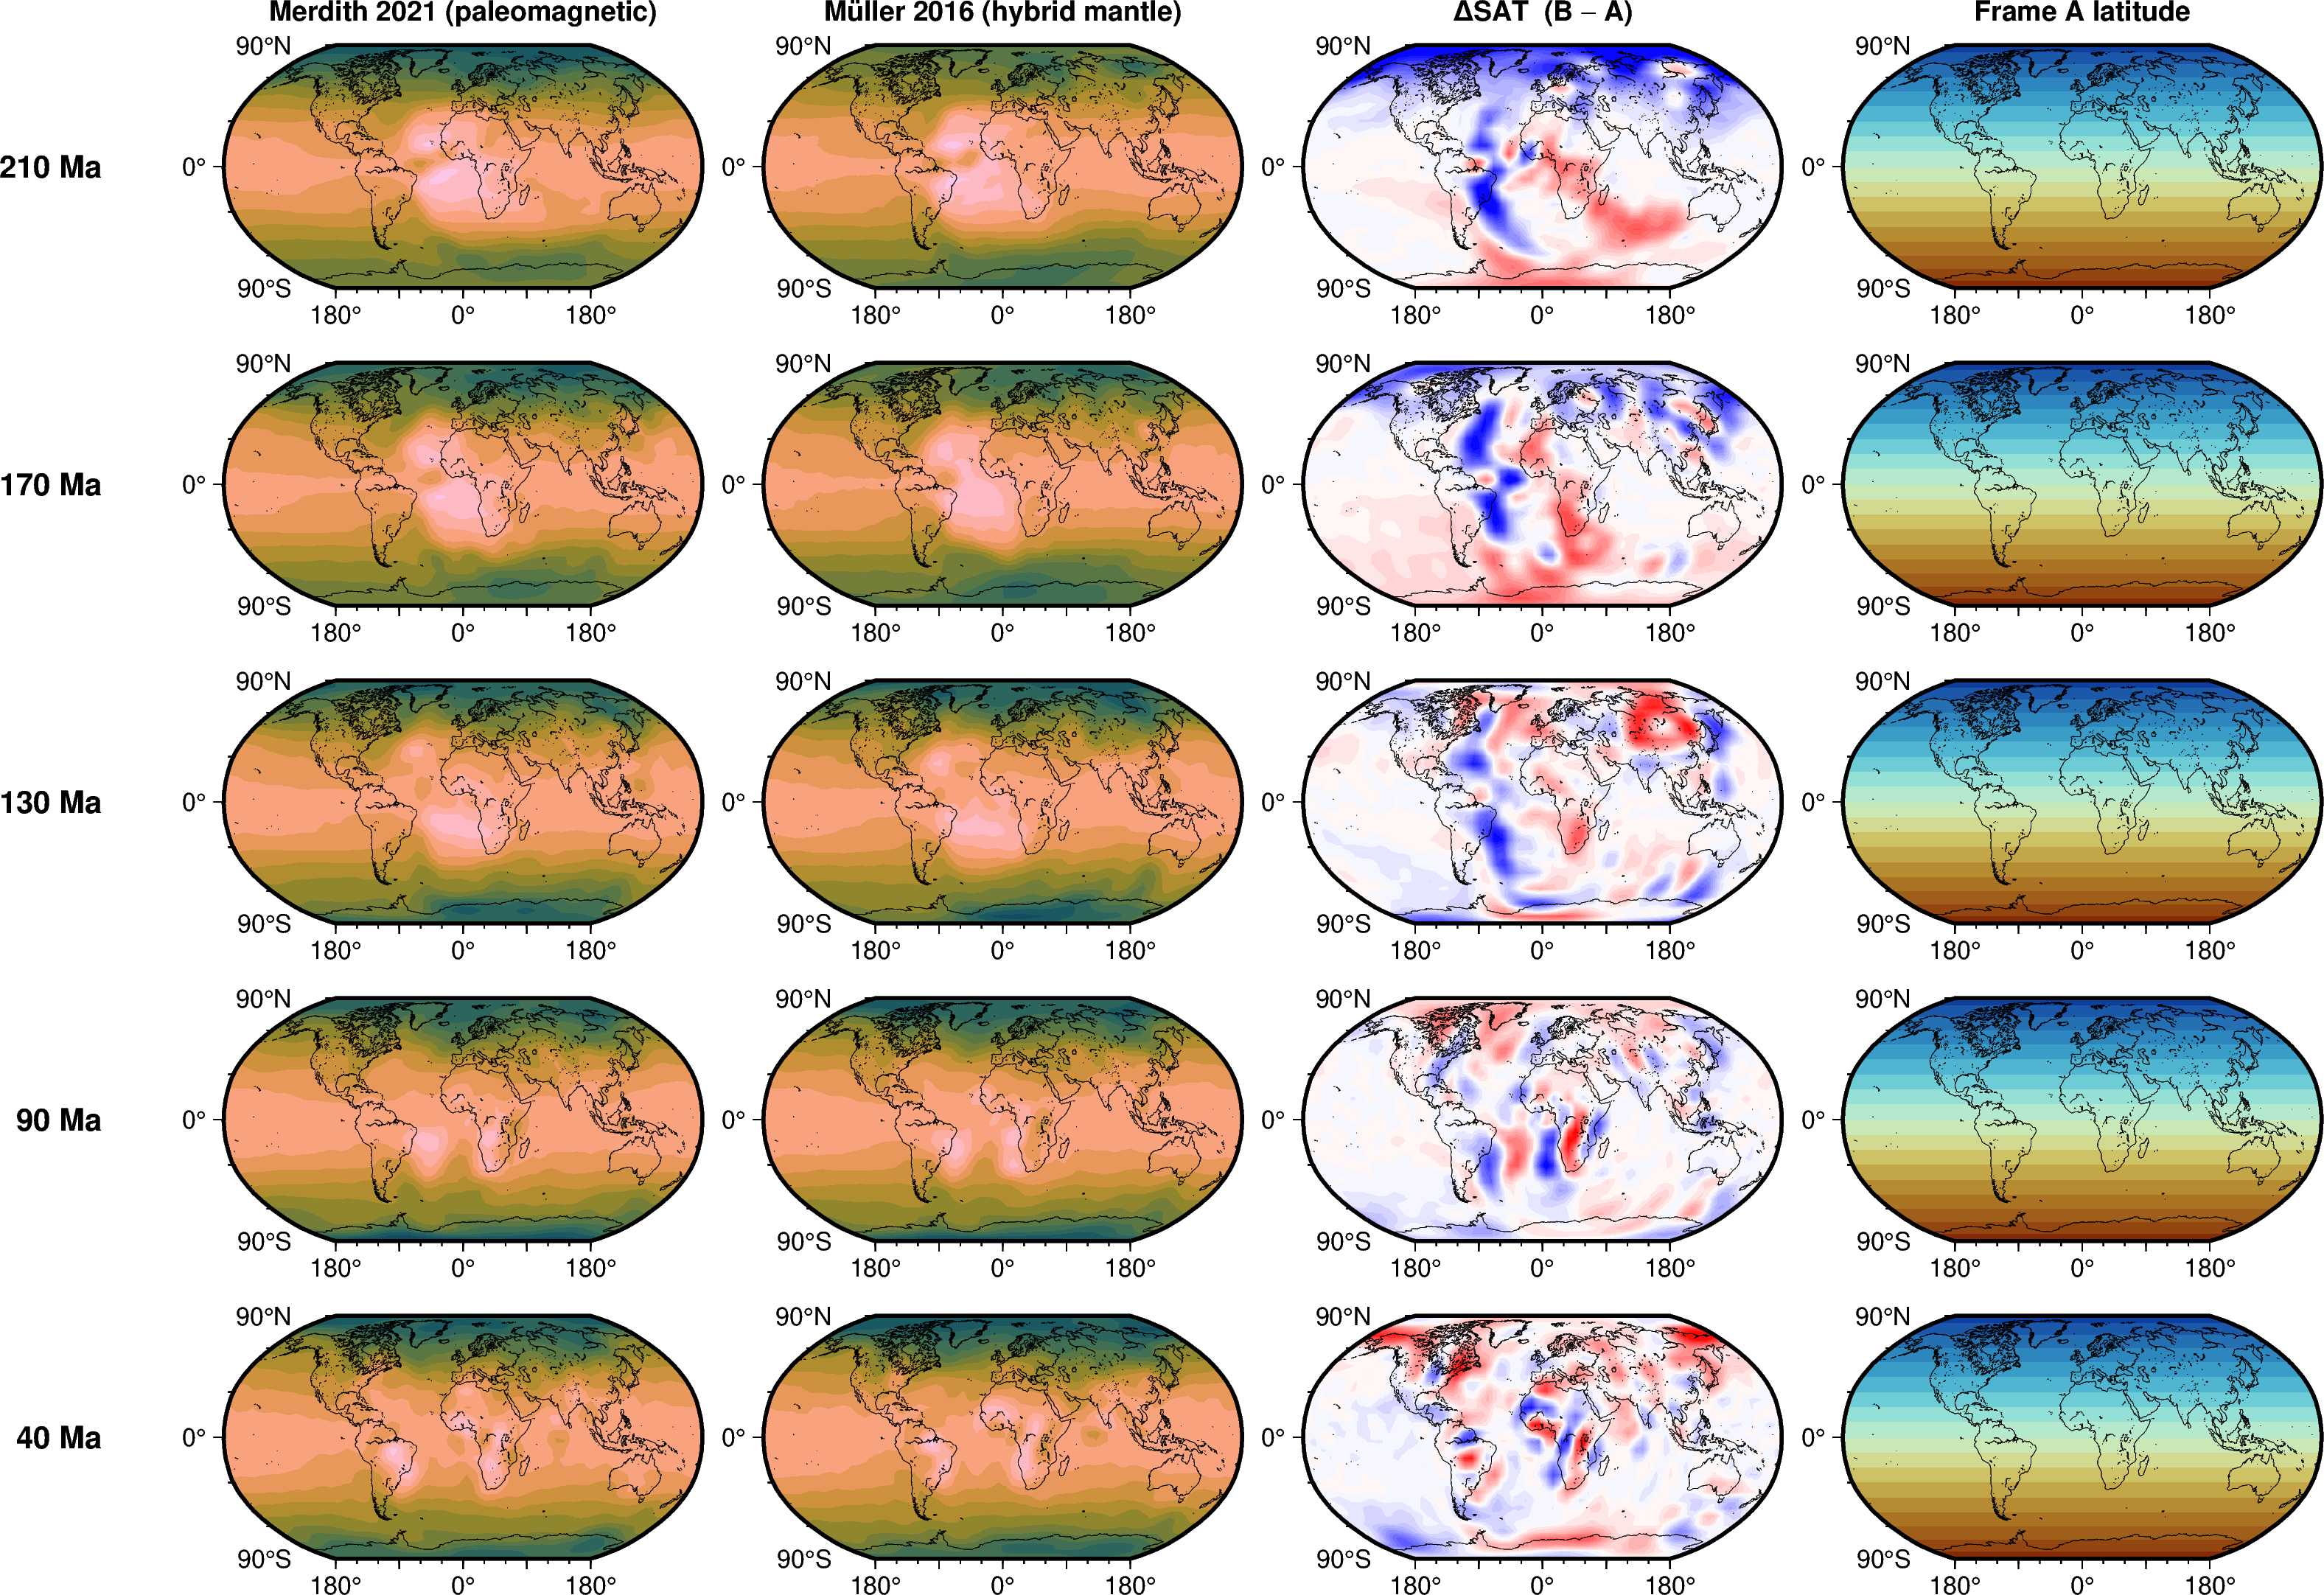

In [25]:
# House-style layout: one pygmt.Figure(), all 20 panels laid out by hand with
# fig.shift_origin() between them. pygmt.subplot forces uniform rectangular
# cells that don't fit Robinson globes, which is why the previous version had
# rows overlapping by half a panel.

PANEL_W_CM = 5.5             # Robinson width per panel (cm)
PANEL_H_CM = PANEL_W_CM / 2  # Robinson aspect ~2:1
COL_GAP_CM = 0.7             # horizontal gap between columns
ROW_GAP_CM = 0.9             # vertical gap between rows
DX_CM = PANEL_W_CM + COL_GAP_CM
DY_CM = PANEL_H_CM + ROW_GAP_CM

PANEL_PROJ = f"N{PANEL_W_CM}c"
COL_TITLES = [FRAME_A_LABEL, FRAME_B_LABEL, "ΔSAT  (B − A)", "Frame A latitude"]

# Pre-build cpts (one per column)
CPT_SAT   = "sat.cpt"
CPT_DIFF  = "diff.cpt"
CPT_LATF  = "latf.cpt"
pygmt.makecpt(cmap="batlow", series=list(SAT_RANGE_C),  background="o", output=CPT_SAT)
pygmt.makecpt(cmap="polar",  series=list(DIFF_RANGE_C), background="o", output=CPT_DIFF)
pygmt.makecpt(cmap="roma",   series=[-90, 90, 10],      background="o", output=CPT_LATF)
CPTS_FOR_COL = [CPT_SAT, CPT_SAT, CPT_DIFF, CPT_LATF]

fig = pygmt.Figure()

# Iterate rows TOP-to-BOTTOM (row 0 = 210 Ma at top, row 4 = 40 Ma at bottom).
# Draw across a row left-to-right, then shift_origin back to col 0 and down one
# row height before the next row.
n_rows = len(SNAPSHOT_AGES_MA)
for row, age in enumerate(SNAPSHOT_AGES_MA):
    fa_sat = refine_for_plot(frame_A[VAR].sel(age=age),
                             lon_name="longitude", lat_name="latitude")
    fb_sat = refine_for_plot(frame_B[VAR].sel(age=age),
                             lon_name="longitude", lat_name="latitude")
    dsat   = refine_for_plot(diff_field(frame_A.sel(age=age), frame_B.sel(age=age)),
                             lon_name="longitude", lat_name="latitude")
    latf   = refine_for_plot(abs_lat_diff(frame_A.sel(age=age), frame_B.sel(age=age)),
                             lon_name="longitude", lat_name="latitude")
    fields = [fa_sat, fb_sat, dsat, latf]

    for col, field in enumerate(fields):
        # Draw one Robinson panel
        fig.grdimage(grid=field, cmap=CPTS_FOR_COL[col],
                     region=REGION, projection=PANEL_PROJ, frame="af")
        fig.coast(region=REGION, projection=PANEL_PROJ,
                  shorelines="0.15p,black")

        # Row label on the leftmost panel of every row
        if col == 0:
            fig.text(text=f"{age} Ma", position="ML",
                     offset="-1.4c/0c", justify="MR",
                     font="10p,Helvetica-Bold,black", no_clip=True,
                     region=REGION, projection=PANEL_PROJ)

        # Column title only on the top row
        if row == 0:
            fig.text(text=COL_TITLES[col], position="TC",
                     offset="0/0.4c", justify="MC",
                     font="9p,Helvetica-Bold,black", no_clip=True,
                     region=REGION, projection=PANEL_PROJ)

        # Move origin RIGHT to the next column (except after the last)
        if col < 3:
            fig.shift_origin(xshift=f"{DX_CM}c")

    # Carriage return: back to col 0, down one row height (except after last row)
    if row < n_rows - 1:
        fig.shift_origin(xshift=f"-{3 * DX_CM}c", yshift=f"-{DY_CM}c")

fig.show(width=1000)


### How to read the map grid

- **Row 1 (210 Ma, mid-Triassic Pangea)** — both frames show a warm greenhouse world (equatorial SAT > 40 °C). The paleomagnetic frame typically puts the supercontinent centred further north than the mantle frame does, so ΔSAT tends to be a positive (warmer) band in the northern hemisphere and negative in the south.
- **Rows 2-4 (170-90 Ma)** — Jurassic-Cretaceous. As the supercontinent breaks up, the two frames diverge further because there is no longer a single-plate anchor connecting the two frames' inferences.
- **Row 5 (40 Ma, mid-Eocene)** — the two frames converge as the paleomagnetic constraint sharpens with more recent data. ΔSAT should be small (< 5 °C over most of the globe).

**Watch for**

- **The magnitude of ΔSAT.** Even at the ages with the tightest paleomagnetic constraints, ΔSAT of 5-10 °C is common. This is the "reference-frame uncertainty" Leonard 2025 quantifies.
- **The systematic sign.** In the 170-130 Ma window, does Frame A tend to be systematically warmer or cooler? A systematic bias identifies a genuine paleoposition disagreement between the frames.
- **Column 4 (latitude field)** — this is what changes when the reference frame changes. The equator location in Frame A determines the tropical latitudinal band; comparing rows shows how much the frame's "0° latitude" moved through the Phanerozoic.


## 4. Latitude × age heatmaps — zonal-mean SAT

Averaging over longitude at each latitude and stacking through age gives a `lat × age` heatmap. Three panels:

- **Frame A** — Merdith 2021 paleomag zonal-mean SAT
- **Frame B** — Müller 2016 mantle zonal-mean SAT
- **Frame B - Frame A** — the difference heatmap


/opt/miniconda3/lib/python3.12/site-packages/pygmt/clib/session.py:1648: RuntimeWarning: Grid may have irregular spacing in the 'y' dimension, but GMT only supports regular spacing. Calculated regular spacing -5.5329413414001465 is assumed in the 'y' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)


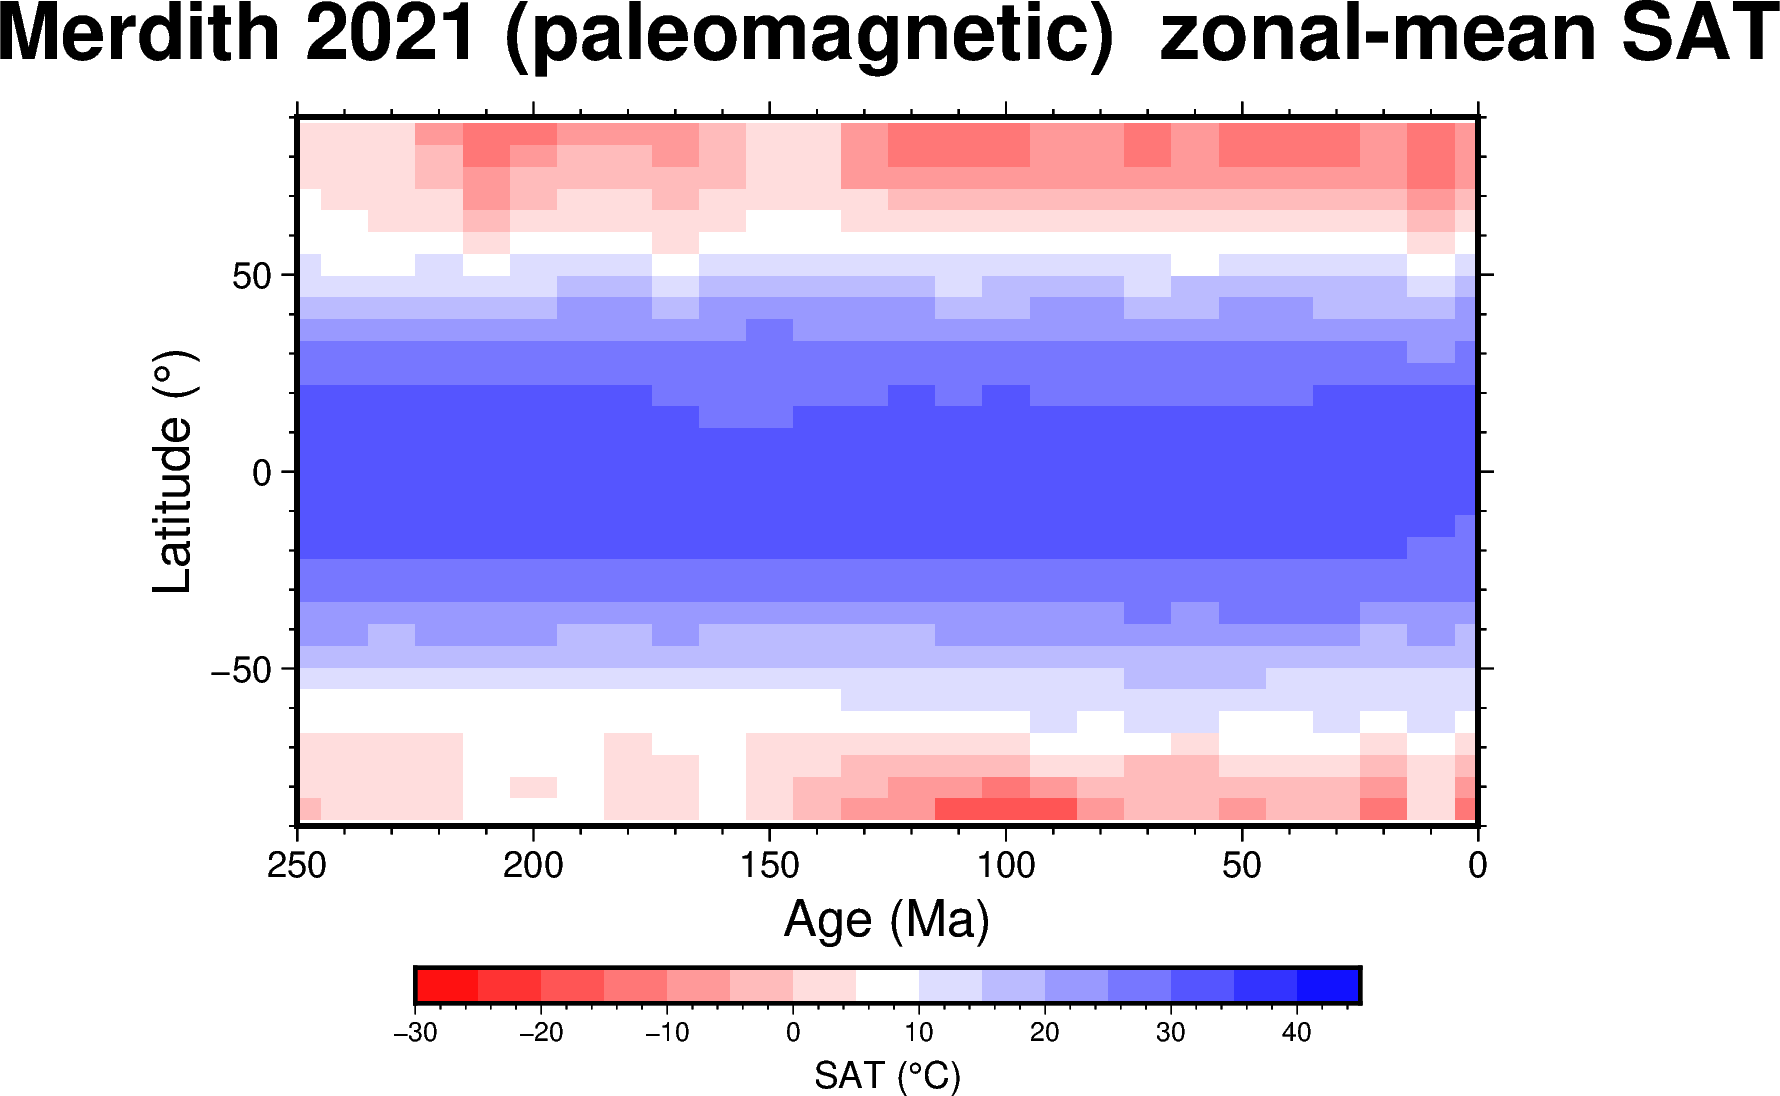

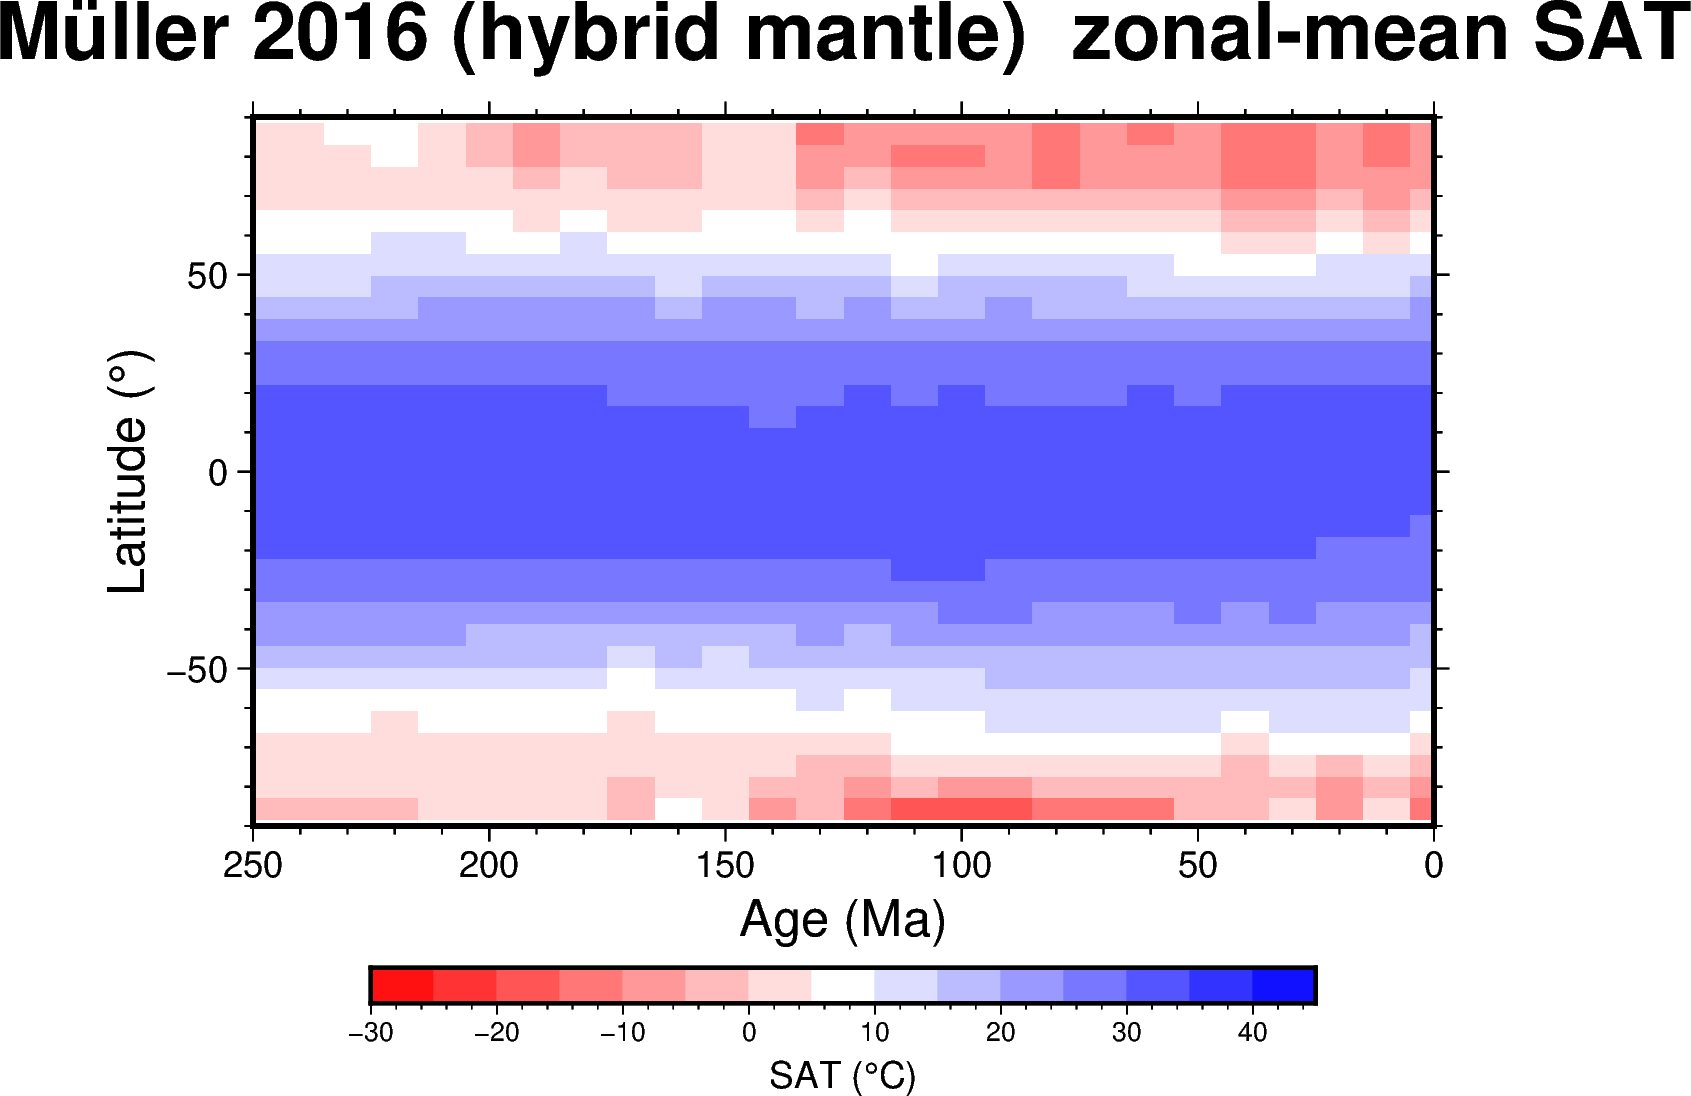

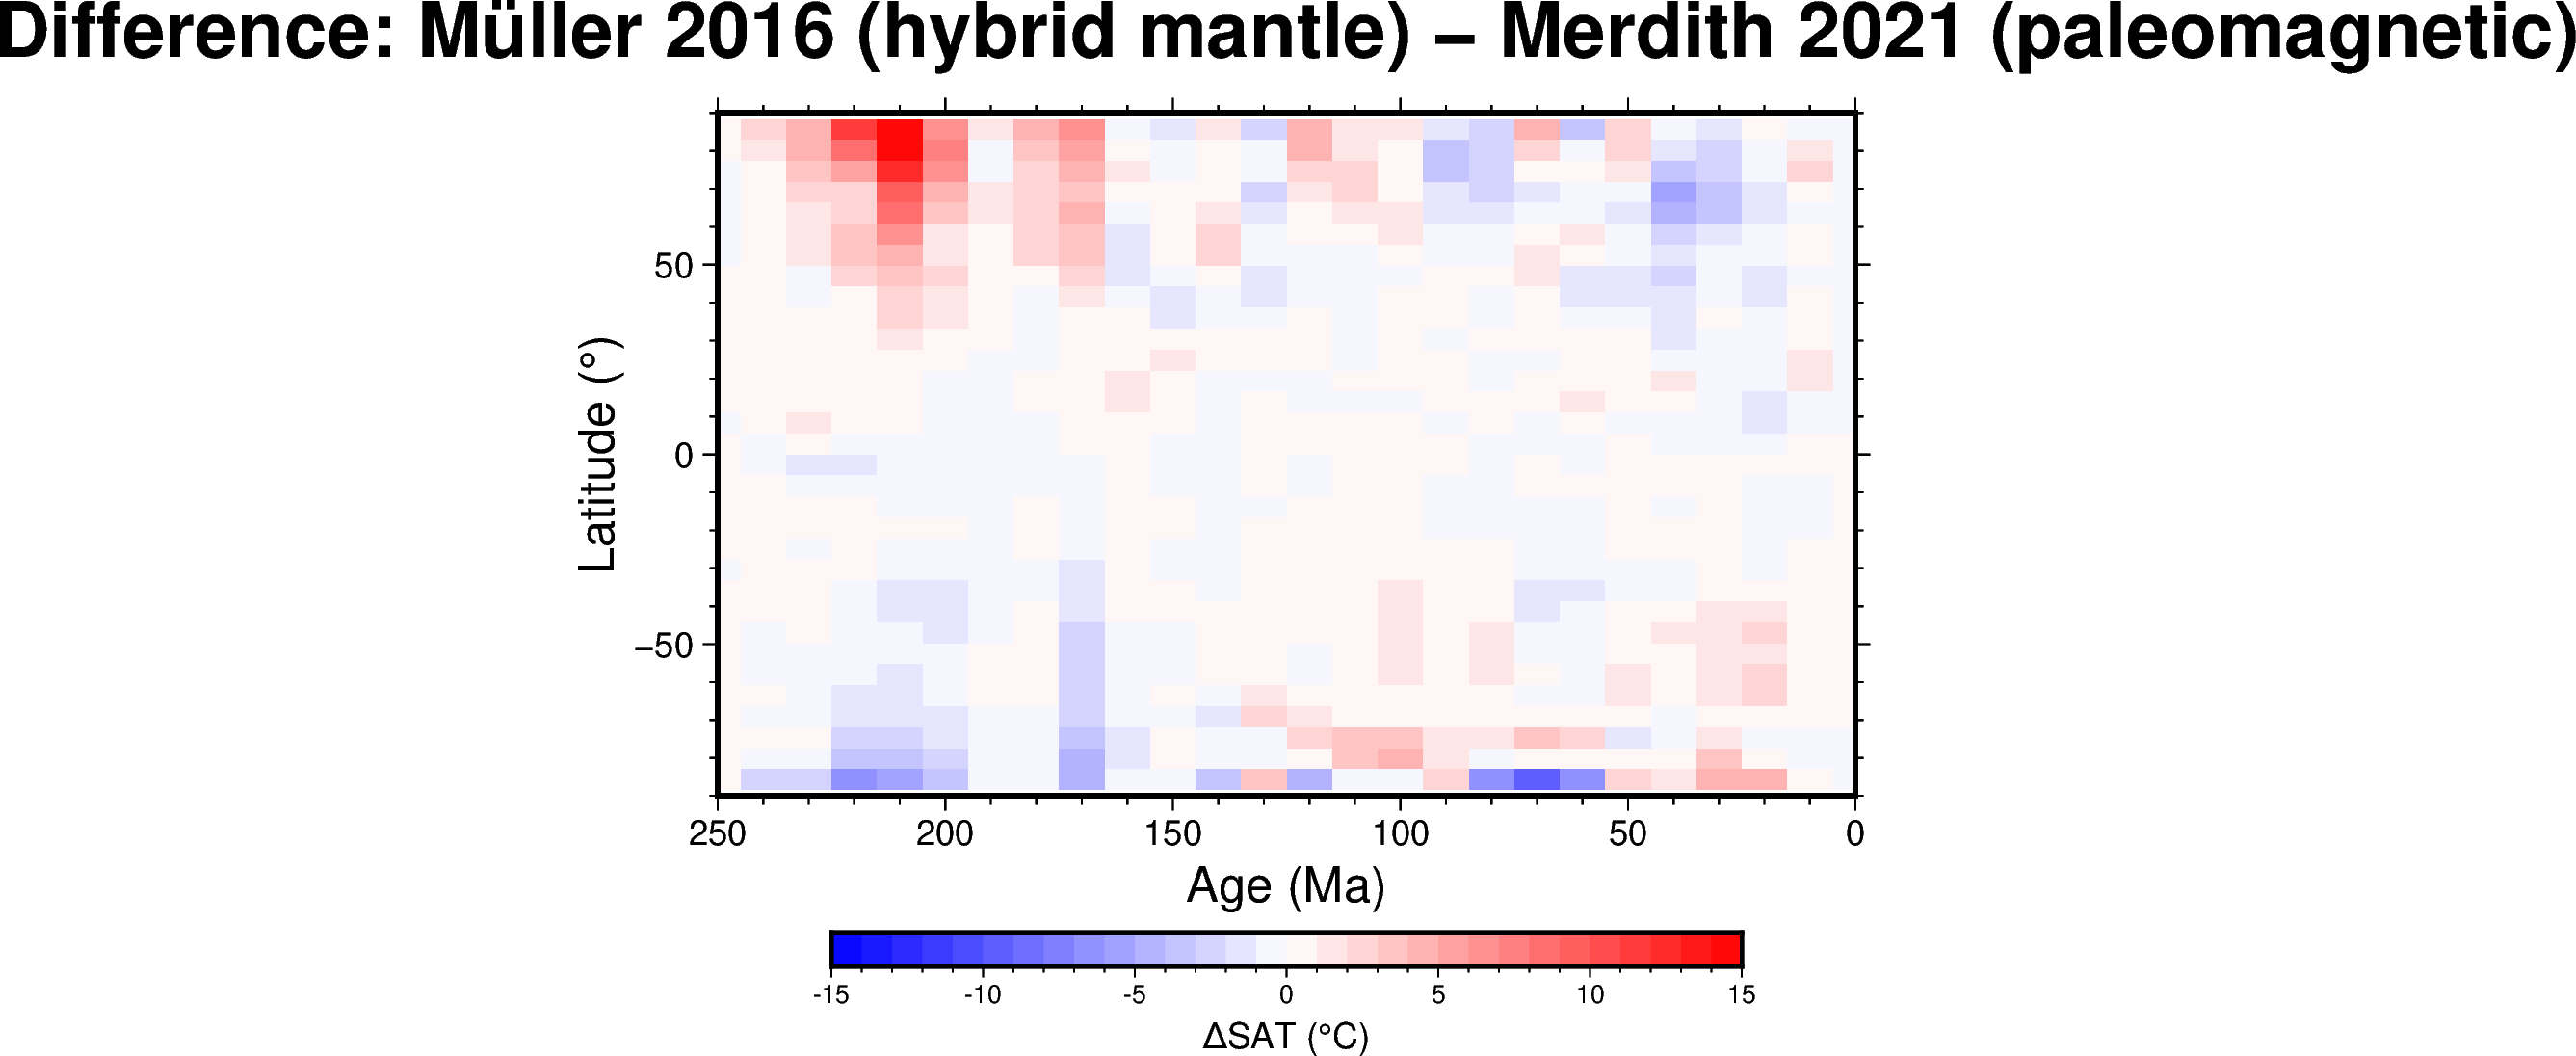

In [26]:
# Zonal (longitude-mean) SAT per frame — turned into pyGMT grdimages
zonal_A = frame_A[VAR].mean(dim="longitude")   # (age, lat)
zonal_B = frame_B[VAR].mean(dim="longitude")
zonal_D = zonal_B - zonal_A

# Each of these is a 2-D grid; wrap as xarray DataArray with proper dim naming
# for pygmt.grdimage. Coord "age" → x-axis, "latitude" → y-axis.
def as_grid(da, name):
    """Return a (lat, age)-ordered DataArray with x/y dim names pyGMT expects."""
    g = da.rename({"age": "x", "latitude": "y"}).transpose("y", "x")
    g.name = name
    return g

gA = as_grid(zonal_A, "sat_A")
gB = as_grid(zonal_B, "sat_B")
gD = as_grid(zonal_D, "sat_diff")

# Three side-by-side heatmap panels — separate pygmt.Figure per panel (house style)
REG_SAT  = [0, float(zonal_A.age.max()), -90, 90]   # x-inverted (older left)
REG_DIFF = [0, float(zonal_A.age.max()), -90, 90]
PROJ = "X-10c/6c"

# Frame A
fig = pygmt.Figure()
pygmt.makecpt(cmap="polar", series=[-30, 45, 5], background="o", reverse=True)
fig.grdimage(grid=gA, cmap=True, region=REG_SAT, projection=PROJ,
             frame=["WSne+t" + FRAME_A_LABEL + "  zonal-mean SAT",
                    "xaf+lAge (Ma)", "yaf+lLatitude (°)"])
fig.colorbar(position="JBC+w8c/0.3c+h+o0/1.2c", frame=["a10f2", "x+lSAT (°C)"])
fig.show(width=750)

# Frame B
fig = pygmt.Figure()
pygmt.makecpt(cmap="polar", series=[-30, 45, 5], background="o", reverse=True)
fig.grdimage(grid=gB, cmap=True, region=REG_SAT, projection=PROJ,
             frame=["WSne+t" + FRAME_B_LABEL + "  zonal-mean SAT",
                    "xaf+lAge (Ma)", "yaf+lLatitude (°)"])
fig.colorbar(position="JBC+w8c/0.3c+h+o0/1.2c", frame=["a10f2", "x+lSAT (°C)"])
fig.show(width=750)

# Difference
fig = pygmt.Figure()
pygmt.makecpt(cmap="polar", series=[-15, 15, 1], background="o")
fig.grdimage(grid=gD, cmap=True, region=REG_DIFF, projection=PROJ,
             frame=["WSne+tDifference: " + FRAME_B_LABEL + " − " + FRAME_A_LABEL,
                    "xaf+lAge (Ma)", "yaf+lLatitude (°)"])
fig.colorbar(position="JBC+w8c/0.3c+h+o0/1.2c", frame=["a5f1", "x+lΔSAT (°C)"])
fig.show(width=750)


### How to read the heatmaps

- **Top + middle panels** — the same underlying PLASIM-GENIE simulation reconstructed into two different reference frames. Both should show the classic equator-warm / pole-cold gradient at every age.
- **Bottom panel** — the difference field. If the two frames agreed perfectly, this panel would be zero everywhere. In practice you'll see red/blue banding at high latitudes at particular ages — that's where the two frames disagree about paleolatitude by enough to shift a whole zonal band into a different climate regime.

**Watch for**

- **Systematic ±ΔSAT bands** — for example, 180-140 Ma, the paleomagnetic frame's northern hemisphere tends to be warmer than the mantle frame's, because the paleomag frame puts the northern continents closer to the equator during that window.
- **Amplitude vs age** — the difference field's peak amplitude at each age is a headline number: how much reference-frame uncertainty contributes to reconstructed zonal SAT. Usually 5-15 °C in the Mesozoic, smaller in the Cenozoic.


## 5. Bonus — global mean SAT time series

Area-weighted global-mean SAT for each frame, plotted through age. The gap between the two curves is a one-liner summary of how much the reference-frame choice shifts the whole planet's inferred temperature history.


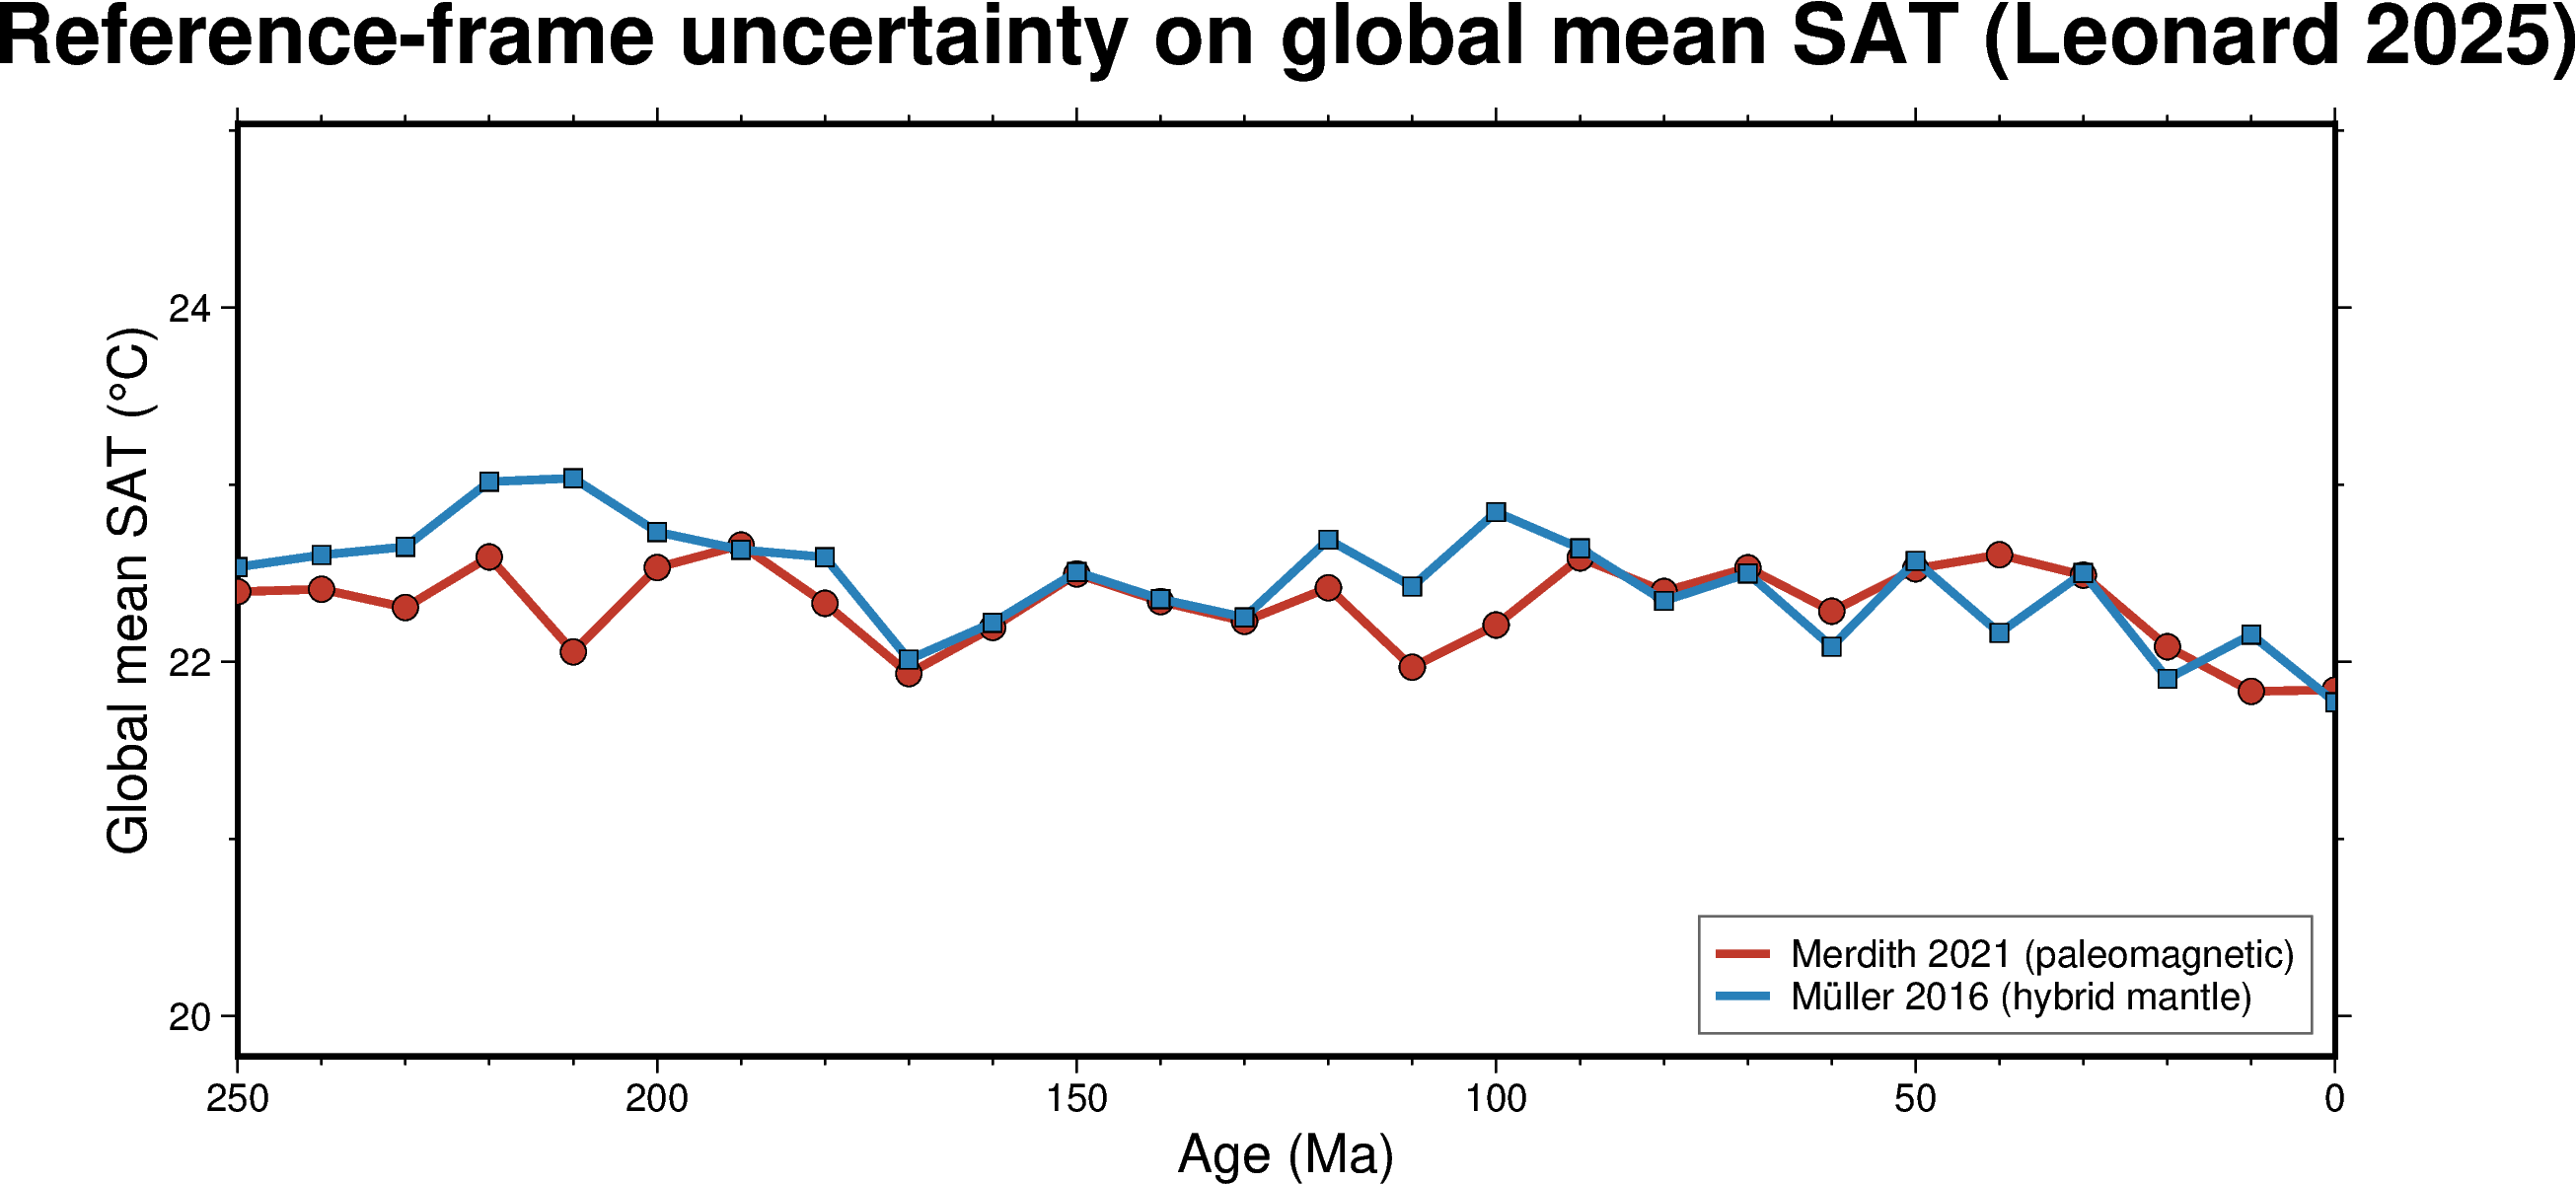


  Mean |GMST gap| between frames: 0.21 °C
  Max  |GMST gap| between frames: 0.98 °C


In [27]:
# Area-weighted global-mean SAT per age
weights = np.cos(np.deg2rad(frame_A.latitude))
weights_norm = weights / weights.sum()
gmst_A = (frame_A[VAR] * weights_norm).sum(dim=("latitude", "longitude")) / frame_A.sizes["longitude"]
gmst_B = (frame_B[VAR] * weights_norm).sum(dim=("latitude", "longitude")) / frame_B.sizes["longitude"]

fig = pygmt.Figure()
Y_MIN, Y_MAX = min(float(gmst_A.min()), float(gmst_B.min())) - 2, \
               max(float(gmst_A.max()), float(gmst_B.max())) + 2
fig.basemap(region=[0, float(gmst_A.age.max()), Y_MIN, Y_MAX],
            projection="X-18c/8c",
            frame=["WSne+tReference-frame uncertainty on global mean SAT (Leonard 2025)",
                   "xa50f10+lAge (Ma)", "yaf+lGlobal mean SAT (°C)"])

# Frame A curve
fig.plot(x=gmst_A.age.values, y=gmst_A.values,
         pen="2p,#c0392b", label=FRAME_A_LABEL)
fig.plot(x=gmst_A.age.values, y=gmst_A.values,
         style="c0.22c", fill="#c0392b", pen="0.3p,black")

# Frame B curve
fig.plot(x=gmst_B.age.values, y=gmst_B.values,
         pen="2p,#2980b9", label=FRAME_B_LABEL)
fig.plot(x=gmst_B.age.values, y=gmst_B.values,
         style="s0.22c", fill="#2980b9", pen="0.3p,black")

fig.legend(position="JBR+jBR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1000)

# Headline
mean_gap = float(np.mean(np.abs(gmst_B.values - gmst_A.values)))
max_gap  = float(np.max(np.abs(gmst_B.values - gmst_A.values)))
print(f"\n  Mean |GMST gap| between frames: {mean_gap:.2f} °C")
print(f"  Max  |GMST gap| between frames: {max_gap:.2f} °C")


## Extend this

- **Swap in the third bundled frame.** Change `FRAME_B_DIR` to `data/leonard_2025_paleoclimate/torsvik2019_paleomag` to compare Merdith 2021 vs Torsvik 2019 paleomag frames. The two paleomag frames should agree more closely than either does with a mantle frame.
- **Change the variable.** The bundled NCs also carry `grid_landsea_mask` and `grid_orography`. Swap `VAR` to `grid_orography` for a paleo-topography comparison, or filter SAT to land-only using the landsea mask.
- **Zoom into a specific age or region.** Change `REGION` from global to (e.g.) `[-40, 40, 0, 60]` for a Tethys-focused comparison, and drop `SNAPSHOT_AGES_MA` to a single age of interest.
- **Fetch the full Leonard archive** from Zenodo to explore all 5 reference frames and 15 climate variables per age, or to compare precipitation instead of SAT.
- **Cross-reference T31 (Plate/mantle frame uncertainty).** T31 quantifies frame uncertainty via reconstructed continent positions; T61 quantifies the downstream climate consequence.

## Related resources

- Leonard 2025 Zenodo archive: <https://zenodo.org/records/15628277>
- Companion notebooks in cluster J: **T45** deep-time paleoclimate snapshots (single frame), **T46** cGENIE SST vs proxies, **T47** SCION/PLASIM-GENIE CO₂ sensitivity, **T48** pySCION Phanerozoic biogeochemistry.

## References

- Leonard, J.S., Mather, B.R., Merdith, A.S., Zahirovic, S., Williams, S.E., Müller, R.D. (2025). Polar wander leads to large differences in past climate. *Communications Earth & Environment*.
- Merdith, A.S., Williams, S.E., Collins, A.S., Tetley, M.G., Mulder, J.A., Blades, M.L., et al. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477.
- Müller, R.D., Seton, M., Zahirovic, S., Williams, S.E., Matthews, K.J., Wright, N.M., et al. (2016). Ocean basin evolution and global-scale plate reorganization events since Pangea breakup. *Annual Review of Earth and Planetary Sciences* 44, 107-138.
- Torsvik, T.H. & Cocks, L.R.M. (2019). *Earth history and palaeogeography*. Cambridge University Press.
- Holden, P.B., Edwards, N.R., Fraedrich, K., Kirk, E., Lunkeit, F. & Zhu, X. (2016). PLASIM-GENIE v1.0: a new intermediate complexity AOGCM. *Geoscientific Model Development* 9(9), 3347-3361.
